In [3]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/flights.db')
print("conncected to flights database")

conncected to flights database


In [4]:
worst_airlines_query = """
SELECT 
    AIRLINE_CODE,
    AIRLINE,
    COUNT(*) AS total_flights,
    ROUND(AVG(DEP_DELAY), 2) AS avg_dep_delay
FROM flights
WHERE DEP_DELAY IS NOT NULL
GROUP BY AIRLINE_CODE, AIRLINE
ORDER BY avg_dep_delay DESC
LIMIT 10;
"""

worst_airlines_df = pd.read_sql_query(worst_airlines_query, conn)
worst_airlines_df

,AIRLINE_CODE,AIRLINE,total_flights,avg_dep_delay
0,B6,JetBlue Airways,109882,18.32
1,F9,Frontier Airlines Inc.,62846,16.03
2,G4,Allegiant Air,50367,13.91
3,NK,Spirit Air Lines,93433,12.98
4,EV,ExpressJet Airlines LLC d/b/a aha!,18028,12.77
5,AA,American Airlines Inc.,372441,12.61
6,YV,Mesa Airlines Inc.,62686,12.28
7,UA,United Air Lines Inc.,249083,11.22
8,WN,Southwest Airlines Co.,557105,10.82
9,OO,SkyWest Airlines Inc.,336153,9.46


In [5]:
import matplotlib.pyplot as plt

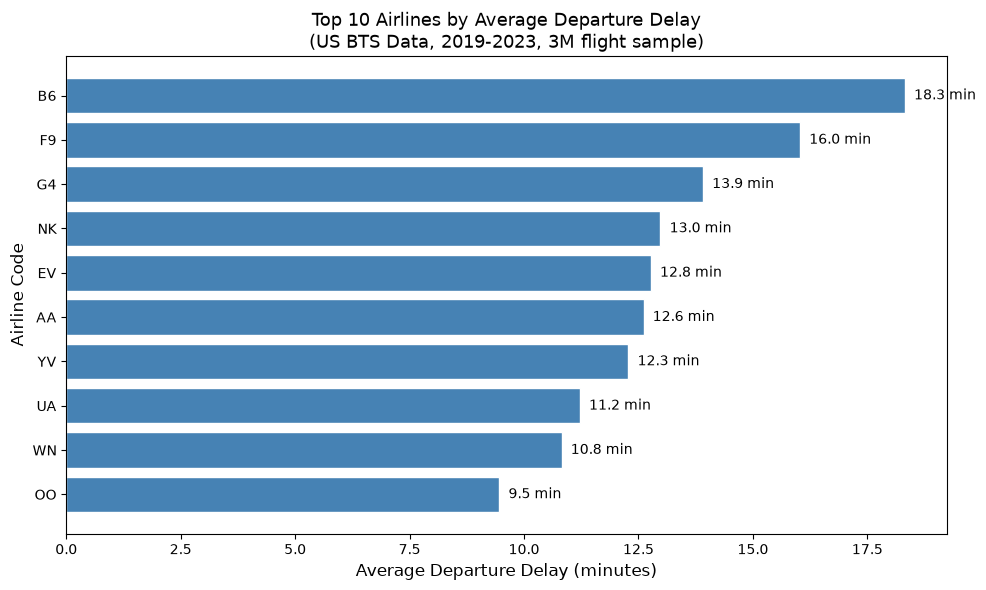

In [7]:
# Create the figure with  size
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
ax.barh(
    worst_airlines_df['AIRLINE_CODE'],
    worst_airlines_df['avg_dep_delay'],
    color='steelblue',
    edgecolor='white'
)

# Reverse y-axis so worst airline is at the top
ax.invert_yaxis()

# Labels and title
ax.set_xlabel('Average Departure Delay (minutes)', fontsize=12)
ax.set_ylabel('Airline Code', fontsize=12)
ax.set_title('Top 10 Airlines by Average Departure Delay\n(US BTS Data, 2019-2023, 3M flight sample)', fontsize=13)

# Add value at the end of each bar so the reader sees exact numbers
for i, value in enumerate(worst_airlines_df['avg_dep_delay']):
    ax.text(value + 0.2, i, f'{value:.1f} min', va='center', fontsize=10)

# Clean up the chart
plt.tight_layout()

# Save disk for inclusion in the README
plt.savefig('../charts/01_worst_airlines.png', dpi=150, bbox_inches='tight')

plt.show()

In [8]:
day_of_week_query = """
SELECT 
    CASE strftime('%w', FL_DATE)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS day_of_week,
    CAST(strftime('%w', FL_DATE) AS INTEGER) AS day_num,
    ROUND(AVG(DEP_DELAY), 2) AS avg_dep_delay,
    ROUND(AVG(ARR_DELAY), 2) AS avg_arr_delay
FROM flights
WHERE DEP_DELAY IS NOT NULL
GROUP BY day_num, day_of_week
ORDER BY day_num;
"""

day_of_week_df = pd.read_sql_query(day_of_week_query, conn)
day_of_week_df

,day_of_week,day_num,avg_dep_delay,avg_arr_delay
0,Sunday,0,11.26,5.29
1,Monday,1,10.59,4.72
2,Tuesday,2,7.99,1.69
3,Wednesday,3,8.44,2.63
4,Thursday,4,10.80,5.56
5,Friday,5,11.39,5.95
6,Saturday,6,10.19,3.67


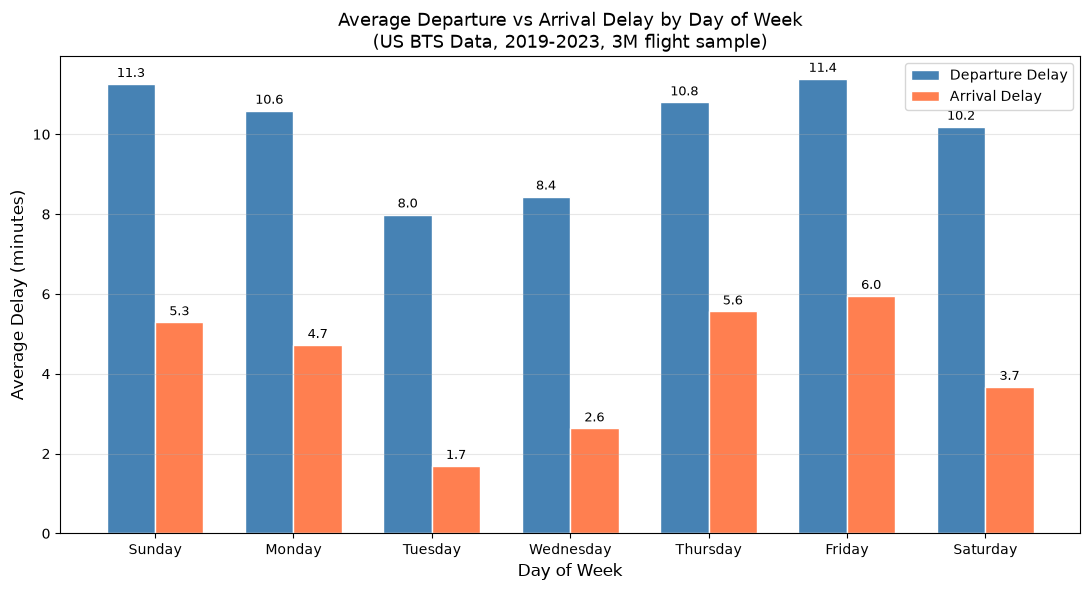

In [9]:
import numpy as np

# Set up the figure
fig, ax = plt.subplots(figsize=(11, 6))

# X-axis positions for the bars
days = day_of_week_df['day_of_week']
x = np.arange(len(days))  # [0, 1, 2, 3, 4, 5, 6]
bar_width = 0.35

# Two sets of bars, offset from each other
bars_dep = ax.bar(
    x - bar_width/2, 
    day_of_week_df['avg_dep_delay'], 
    bar_width, 
    label='Departure Delay', 
    color='steelblue', 
    edgecolor='white'
)

bars_arr = ax.bar(
    x + bar_width/2, 
    day_of_week_df['avg_arr_delay'], 
    bar_width, 
    label='Arrival Delay', 
    color='coral', 
    edgecolor='white'
)

# Labels and title
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Delay (minutes)', fontsize=12)
ax.set_title('Average Departure vs Arrival Delay by Day of Week\n(US BTS Data, 2019-2023, 3M flight sample)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.legend()

# Add numeric values on top of each bar
for bar in bars_dep:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in bars_arr:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Clean up
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save
plt.savefig('../charts/02_day_of_week.png', dpi=150, bbox_inches='tight')

plt.show()

In [10]:

worst_airports_query = """
SELECT 
    ORIGIN, 
    ORIGIN_CITY, 
    COUNT(*) AS total_flights, 
    ROUND(AVG(DEP_DELAY), 2) AS avg_dep_delay  
FROM flights 
WHERE DEP_DELAY IS NOT NULL 
GROUP BY ORIGIN, ORIGIN_CITY 
HAVING COUNT(*) >= 10000
ORDER BY avg_dep_delay DESC 
LIMIT 10;
"""

worst_airports_df = pd.read_sql_query(worst_airports_query, conn)
worst_airports_df

,ORIGIN,ORIGIN_CITY,total_flights,avg_dep_delay
0,EWR,"Newark, NJ",50991,16.06
1,FLL,"Fort Lauderdale, FL",39210,14.67
2,SJU,"San Juan, PR",12773,14.64
3,MCO,"Orlando, FL",62168,14.57
4,MDW,"Chicago, IL",33666,13.79
5,MIA,"Miami, FL",41062,13.53
6,DEN,"Denver, CO",116726,13.42
7,JFK,"New York, NY",49107,13.32
8,PBI,"West Palm Beach/Palm Beach, FL",10639,13.24
9,BWI,"Baltimore, MD",39676,12.93


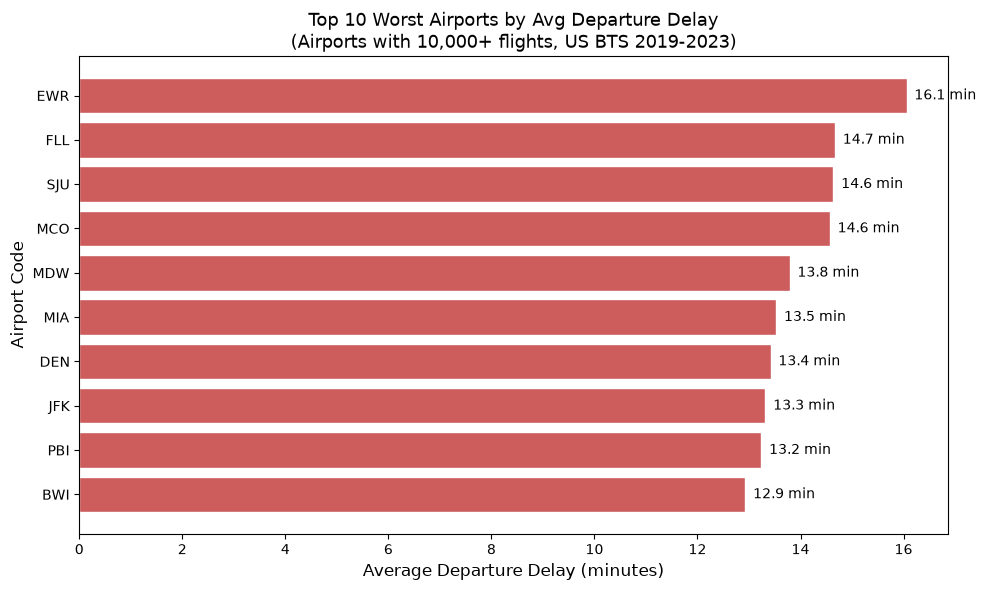

In [11]:

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    worst_airports_df['ORIGIN'],
    worst_airports_df['avg_dep_delay'],
    color='indianred',
    edgecolor='white'
)

ax.invert_yaxis()

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=12)
ax.set_ylabel('Airport Code', fontsize=12)
ax.set_title('Top 10 Worst Airports by Avg Departure Delay\n(Airports with 10,000+ flights, US BTS 2019-2023)', fontsize=13)

for i, value in enumerate(worst_airports_df['avg_dep_delay']):
    ax.text(value + 0.15, i, f'{value:.1f} min', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/03_worst_airports.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
delay_causes_query = """
SELECT 
    ROUND(AVG(DELAY_DUE_CARRIER), 2) AS avg_carrier_delay,
    ROUND(AVG(DELAY_DUE_WEATHER), 2) AS avg_weather_delay,
    ROUND(AVG(DELAY_DUE_NAS), 2) AS avg_nas_delay,
    ROUND(AVG(DELAY_DUE_SECURITY), 2) AS avg_security_delay,
    ROUND(AVG(DELAY_DUE_LATE_AIRCRAFT), 2) AS avg_late_aircraft_delay
FROM flights
WHERE ARR_DELAY >= 15;
"""

delay_causes_df = pd.read_sql_query(delay_causes_query, conn)
delay_causes_df

,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay
0,24.76,3.99,13.16,0.15,25.47


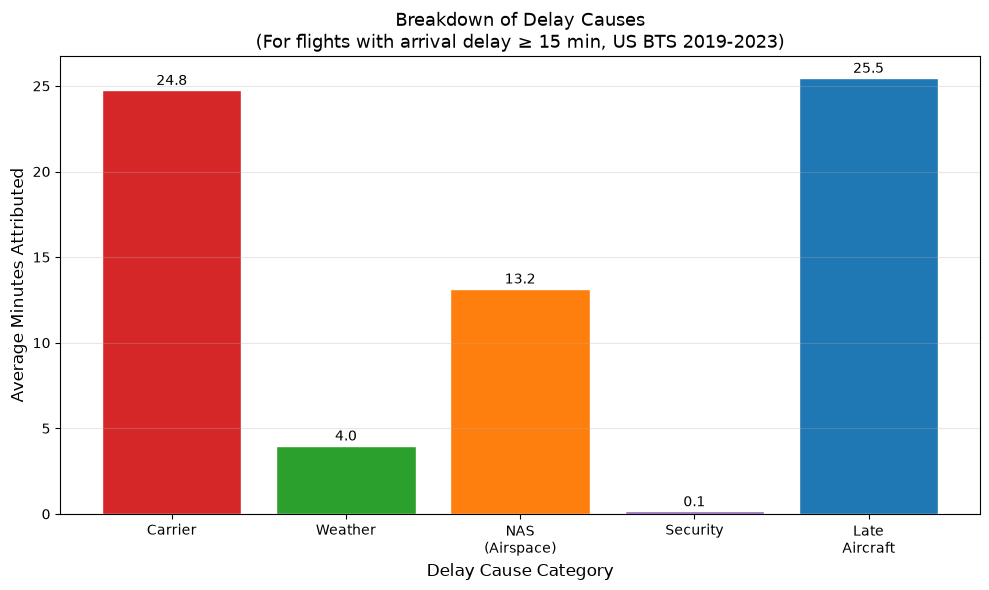

In [13]:
# Reshape for plotting
causes = ['Carrier', 'Weather', 'NAS\n(Airspace)', 'Security', 'Late\nAircraft']
values = [
    delay_causes_df['avg_carrier_delay'].iloc[0],
    delay_causes_df['avg_weather_delay'].iloc[0],
    delay_causes_df['avg_nas_delay'].iloc[0],
    delay_causes_df['avg_security_delay'].iloc[0],
    delay_causes_df['avg_late_aircraft_delay'].iloc[0]
]

# chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(causes, values, color=['#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#1f77b4'], edgecolor='white')

ax.set_xlabel('Delay Cause Category', fontsize=12)
ax.set_ylabel('Average Minutes Attributed', fontsize=12)
ax.set_title('Breakdown of Delay Causes\n(For flights with arrival delay ≥ 15 min, US BTS 2019-2023)', fontsize=13)

# Numeric labels on each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}', ha='center', fontsize=10)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../charts/04_delay_causes.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
monthly_query = """
SELECT 
    CAST(strftime('%m', FL_DATE) AS INTEGER) AS month_num,
    CASE strftime('%m', FL_DATE)
        WHEN '01' THEN 'Jan' WHEN '02' THEN 'Feb' WHEN '03' THEN 'Mar'
        WHEN '04' THEN 'Apr' WHEN '05' THEN 'May' WHEN '06' THEN 'Jun'
        WHEN '07' THEN 'Jul' WHEN '08' THEN 'Aug' WHEN '09' THEN 'Sep'
        WHEN '10' THEN 'Oct' WHEN '11' THEN 'Nov' WHEN '12' THEN 'Dec'
    END AS month_name,
    ROUND(AVG(DEP_DELAY), 2) AS avg_dep_delay
FROM flights
WHERE DEP_DELAY IS NOT NULL
GROUP BY month_num, month_name
ORDER BY month_num;
"""

monthly_df = pd.read_sql_query(monthly_query, conn)
monthly_df

,month_num,month_name,avg_dep_delay
0,1,Jan,8.72
1,2,Feb,9.82
2,3,Mar,8.32
3,4,Apr,9.60
4,5,May,9.43
5,6,Jun,15.05
6,7,Jul,14.67
7,8,Aug,11.85
8,9,Sep,5.78
9,10,Oct,7.33


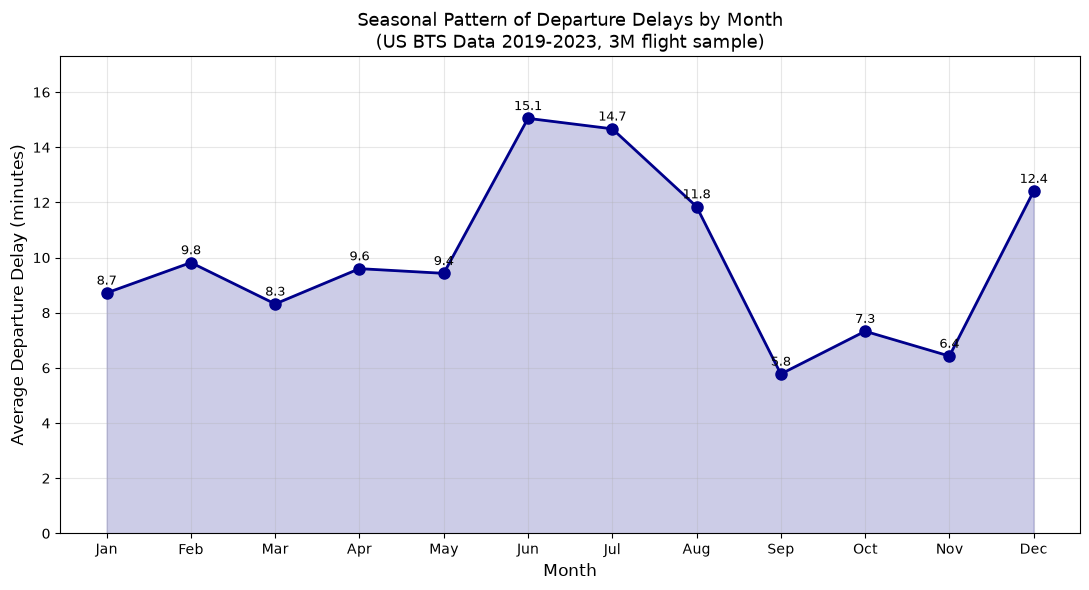

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    monthly_df['month_name'],
    monthly_df['avg_dep_delay'],
    marker='o',
    linewidth=2,
    markersize=8,
    color='darkblue'
)

# Fill under the line for visual emphasis
ax.fill_between(monthly_df['month_name'], monthly_df['avg_dep_delay'], alpha=0.2, color='darkblue')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Departure Delay (minutes)', fontsize=12)
ax.set_title('Seasonal Pattern of Departure Delays by Month\n(US BTS Data 2019-2023, 3M flight sample)', fontsize=13)

# Numeric values above each point
for i, val in enumerate(monthly_df['avg_dep_delay']):
    ax.text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=9)

ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(monthly_df['avg_dep_delay']) * 1.15)  # leave room for labels above
plt.tight_layout()
plt.savefig('../charts/05_seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()